In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy import text
import os
from dotenv import load_dotenv
from sqlalchemy.pool import NullPool



In [7]:
load_dotenv(dotenv_path=".env", override=True)
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")

print("USER:", USER)
print("HOST:", HOST)
print("PORT:", PORT)

DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

engine = create_engine(
    DATABASE_URL,
    poolclass=NullPool
)

try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

USER: postgres.belcfffqjrnqrcqavsxz
HOST: aws-1-us-east-2.pooler.supabase.com
PORT: 6543


Connection successful!


In [16]:
paymentMethod = """
SELECT p.payment_method, COUNT(*) AS total   
FROM facts_sales f                           
JOIN dim_payment p                           
ON f.id_payment_method = p.id_payment_method 
GROUP BY payment_method     
"""
bigClients = """
SELECT quantity, COUNT(*) AS total           
FROM facts_sales                             
GROUP BY quantity                            
ORDER BY total DESC;  
"""
salesByCat = """
SELECT c.category, COUNT(*) AS total         
FROM facts_sales f                           
JOIN dim_category c                          
ON f.id_category = c.id_category             
GROUP BY category; 
"""
salesByMonth = """
SELECT d.month, COUNT(*) as total            
FROM facts_sales f                           
JOIN dim_date d                              
ON f.id_date = d.id_date                     
GROUP BY month                               
ORDER BY month ASC
"""

querys = [salesByCat, bigClients, paymentMethod, salesByMonth]
def run_query(query):
    with engine.connect() as connection:
        result = connection.execute(text(query))
        return pd.DataFrame(result.fetchall(), columns=result.keys())
    
dfs = [run_query(query) for query in querys]
#almaceno outputs en lista de dataframes

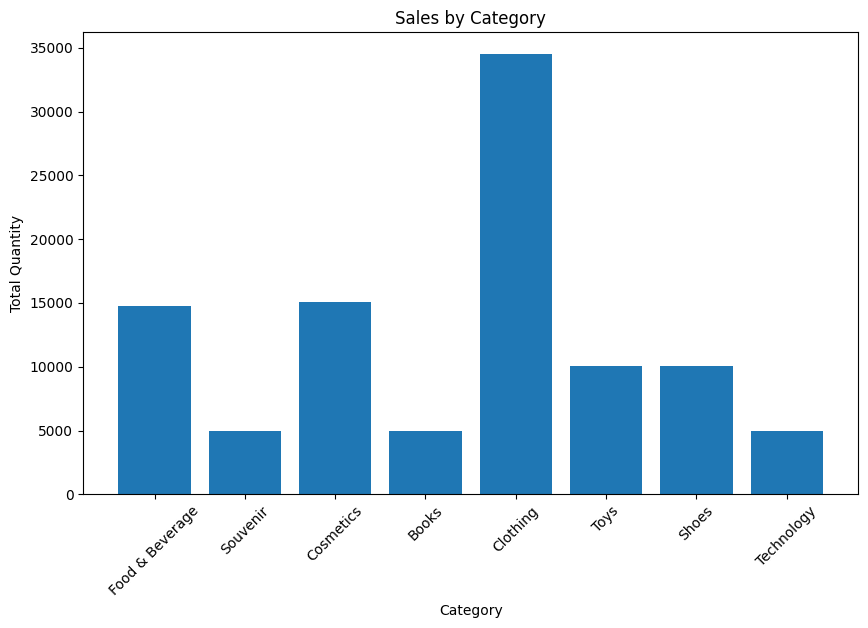

In [9]:
plt.figure(figsize=(10, 6))
plt.bar(dfs[0]['category'], dfs[0]['total'])
plt.xlabel('Category')
plt.ylabel('Total Quantity')
plt.title('Sales by Category')
plt.xticks(rotation=45)
plt.show()

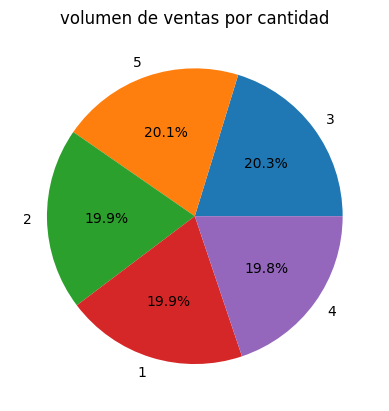

In [41]:
plt.pie(dfs[1]['total'], labels=dfs[1]['quantity'], autopct='%1.1f%%')
plt.title('volumen de ventas por cantidad')
plt.show()

In [11]:
dfs[1].describe()

,quantity,total
count,5.000000,5.000000
mean,3.000000,19891.400000
std,1.581139,176.020737
min,1.000000,19723.000000
25%,2.000000,19767.000000
50%,3.000000,19828.000000
75%,4.000000,19990.000000
max,5.000000,20149.000000


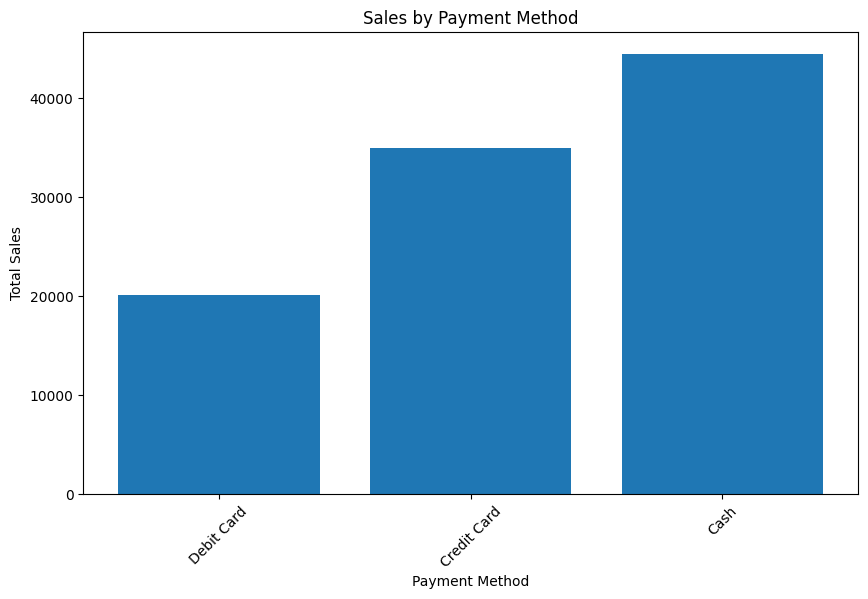

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(dfs[2]['payment_method'], dfs[2]['total'])
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.title('Metodos de pago ')
plt.xticks(rotation=45)
plt.show()

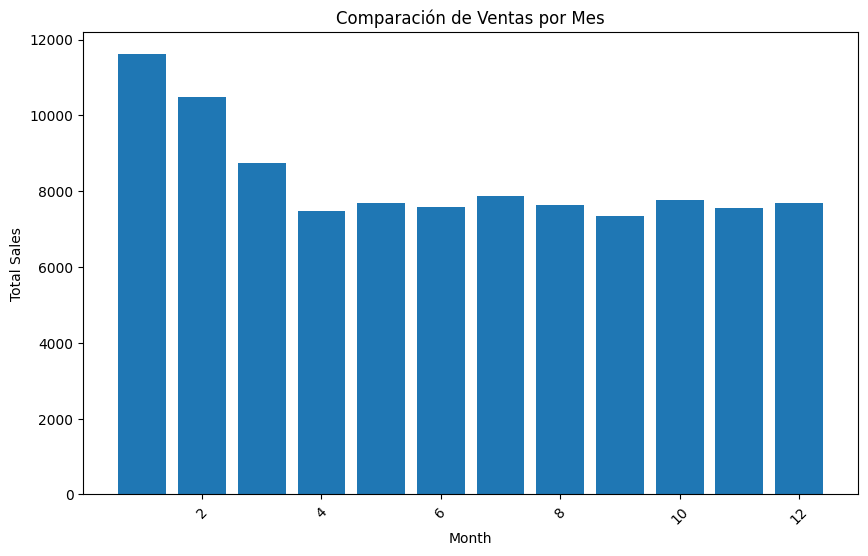

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(dfs[3]['month'], dfs[3]['total']) 
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Comparación de Ventas por Mes')
plt.xticks(rotation=45)
plt.show()